In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import xarray as xr
import cartopy.crs as ccrs

In [8]:
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
ds = xr.open_dataset('GEOS-CF_AirQuality_20180101_0030z.nc4')

In [3]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

# Ozone Analysis

### i. Plot a map for O3 concentrations in parts per billion.



/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:712: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:712: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)


/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:712: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


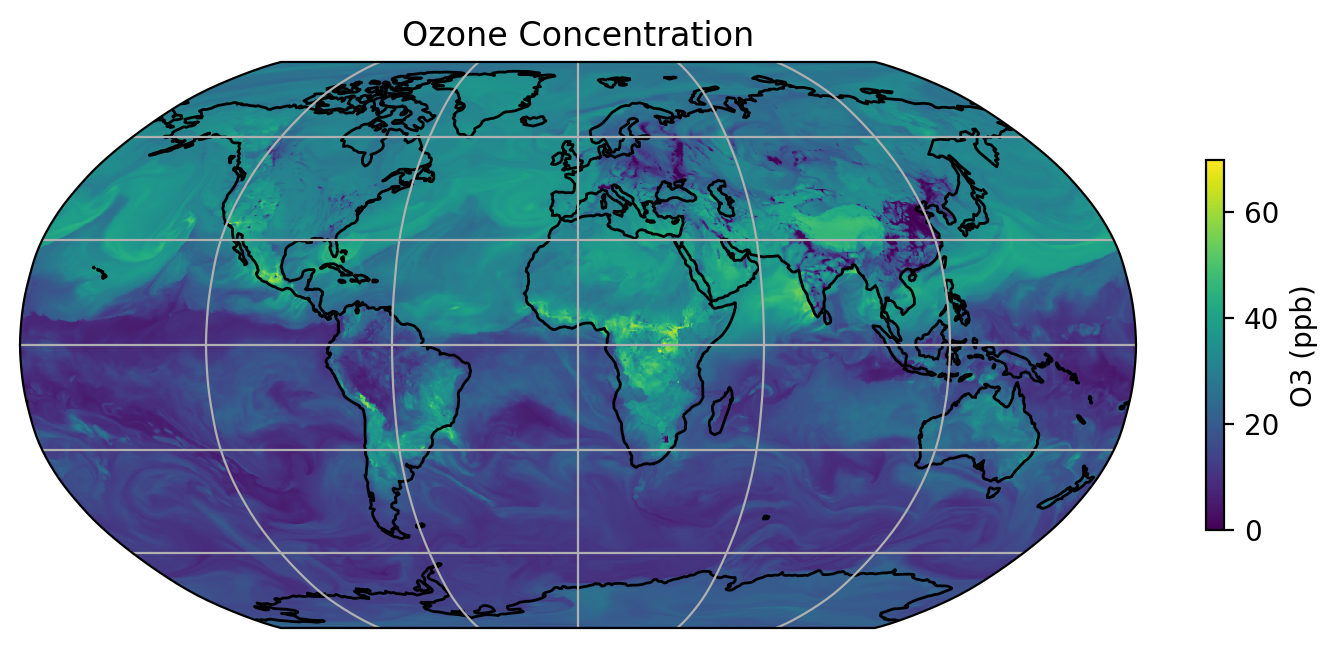

In [6]:
o3 = ds.O3 # making the var for o3
o3 = ds.O3 * 1e9 # converting mol mol^-1 to ppb

# plotting
fig = plt.figure(figsize=(9,6), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())
o3.plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'shrink': 0.4, 'label': 'O3 (ppb)'}) 
ax.set_title("Ozone Concentration")
ax.coastlines()
ax.gridlines()

/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:712: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:712: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/kaylena/anaconda3/lib/python3.11/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersect

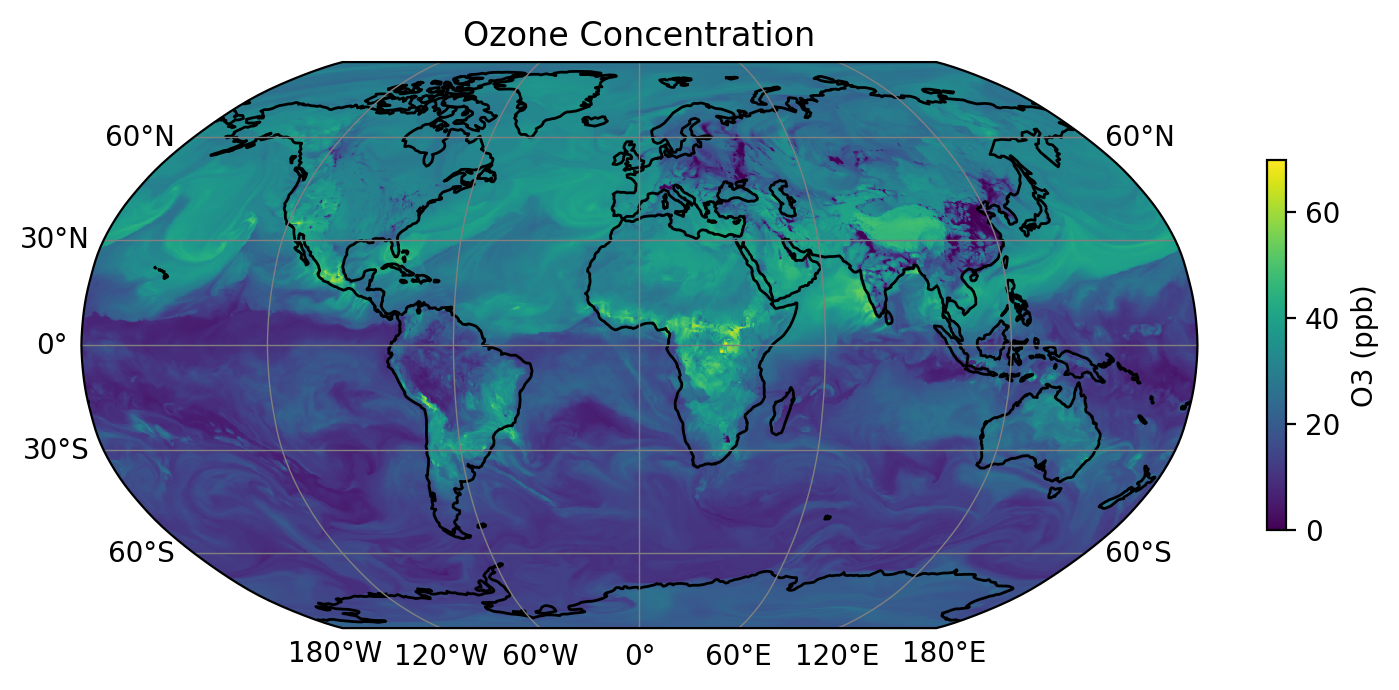

In [19]:
fig = plt.figure(figsize=(9,6), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())

o3.plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'shrink': 0.4, 'label': 'O3 (ppb)'})

ax.set_title("Ozone Concentration")
ax.coastlines()

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='-')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

### ii. Answer the following questions:

a. Where is O3 qualitatively high?

b. What latitude and longitude is O3 highest?

c. Where is O3 qualitatively low?

d. What latitude and longitude is O3 lowest?

e. What is the O3 concentration over LA?

f. What is the O3 concentration over Hawaii?

### Answers:

a. O3 is high generally in the middle of Africa and the southern most region of North American.

b. O3 is highest at lat: 34.5, and lon: -118.75

c. O3 is generally low over the ocean

d. O3 is lowest at lat: 53.0 and lon: 38.5

e. O3 concentration over LA is 45.40 ppb

f. O3 concentration over Hawaii is 26.28 ppb

In [15]:
max_loc = o3.where(o3 == o3.max(), drop=True)
print(max_loc.lat.values, max_loc.lon.values)

[34.5] [-118.75]


In [16]:
min_loc = o3.where(o3 == o3.min(), drop=True)
print(min_loc.lat.values, min_loc.lon.values)

[53.   53.25 55.75 56.  ] [38.5  38.75 39.   39.25 39.5  73.25 73.5  73.75]


In [10]:
o3.sel(lat=[34.052235], lon=[-118.243683], method="nearest") # Los Angeles

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[45.401974]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 34.0
  * lon      (lon) float64 8B -118.2
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1000000000000000.0
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1000000000000000.0
    vmax:            1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

In [11]:
o3.sel(lat=[19.8968], lon=[155.5828], method="nearest") # Hawaii

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[26.28076]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 20.0
  * lon      (lon) float64 8B 155.5
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1000000000000000.0
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1000000000000000.0
    vmax:            1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

# Final Project Pitch

i. I am thinking of working with TEMPO NO2 column data from NASA Earth Data.

ii. I want to do an emulation analysis to predict NO2 from wildfires

iii. This work is important because we can better understand the regional impacts from NO2 due to wildfire smoke and plumes